# 4.2 新計算怎樣加回去，又保留已有表示？


假設一個位置已經有兩格 `[1,2]`，分支算出修正 `[2,4]`。我們希望用新資訊，又不讓原表示必須整份透過新分支，所以留一條直接路，最後逐格相加，得 `[3,6]`。

這叫**殘差連線**，寫成 `y=x+f(x)`。x 是已有表示，f(x) 是修正；兩邊必須同形狀。本節用簡單 `f(x)=2*x` 看清兩路，並測試輸出對輸入的敏感度。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

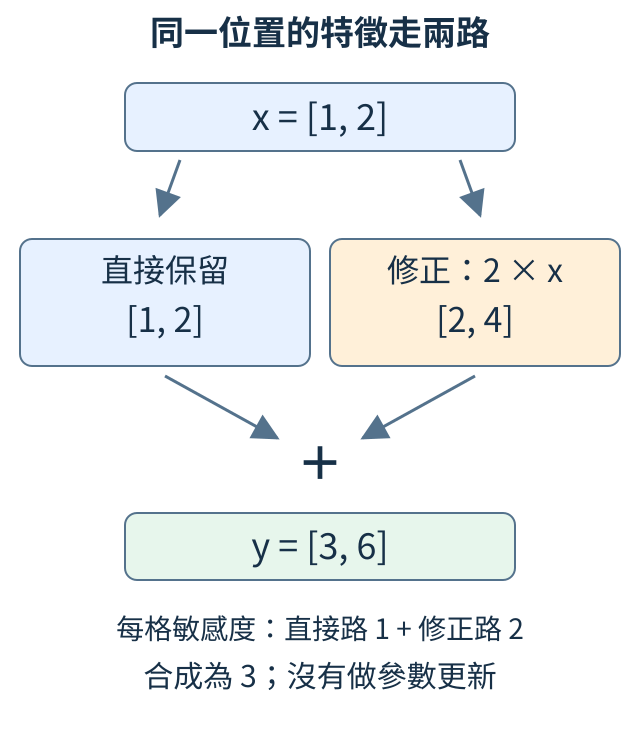

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-04-residual.svg")))

圖中直接路保留 `[1,2]`，修正路產生 `[2,4]`。前向數值相加，反向求導時同一格也有兩條影響路徑。


In [3]:
import torch

x = torch.tensor([1.0, 2.0], requires_grad=True)
correction = 2 * x
y = x + correction
y.sum().backward()
print("結果", y.detach())
print("對輸入的敏感度", x.grad)
assert torch.equal(x.grad, torch.tensor([3.0, 3.0]))

結果 tensor([3., 6.])
對輸入的敏感度 tensor([3., 3.])


輸出印 `[3,6]`，梯度印 `[3,3]`。為什麼每格敏感度是 3？讓某格 x 微增 0.001，直接路使相應輸出增 0.001，乘二路再增 0.002，總共增 0.003。因此兩路影響是 1+2=3，與鏈式法則的各路求導相容。

`y.sum()` 只為把兩格輸出加成單個數，以便測敏感度；它不是文字答案的 loss。程式也沒有可調分支參數或更新步驟。

殘差讓已有資訊沿直接路往後算，也讓梯度沿這條路往前層傳回。即使修正暫時接近 0，直接路仍有一份資訊與敏感度。它不保證訓練永不失敗，也不表示所有原文能完整還原；作用是讓每層可在已有表示上學修正。

練習把 `correction=2*x` 改成 `0*x`，輸出變 `[1,2]`，梯度變 `[1,1]`，將斷言同步修改再核對。分支不提供改變時，主路仍工作。

<details>
<summary>補充與重做</summary>

兩格屬於同一位置的特徵，不是兩個文字位置。更一般的導數寫 `I+df/dx`，I 代表各特徵沿直接路原樣傳遞。本例不需矩陣微積分，只要看每格 1+2；多路求導背景見 [1.10](https://birdhackor.github.io/tiny-perceptron-vlm/1.10.html)。

</details>
